In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [21]:
DATA_DIR = Path("../data")

weather = pd.read_csv(
    DATA_DIR / "dengue_features_train.csv",
    parse_dates=["week_start_date"],
)

weather = weather.sort_values(
    ["city", "week_start_date"]
).reset_index(drop=True)

weather_columns = [
    "precipitation_amt_mm",
    "reanalysis_relative_humidity_percent",
    "reanalysis_air_temp_k",
]

# Celsius is easier to interpret.
weather["temperature_c"] = (
    weather["reanalysis_air_temp_k"] - 273.15
)
weather_columns[-1] = "temperature_c"

# Summarize conditions BEFORE each prediction week.
# Compute these before filtering to the holdout so earlier history is retained.
summary_columns = []

for column in weather_columns:
    for window in [4, 8, 16]:
        name = f"{column}_previous_{window}w_mean"

        weather[name] = (
            weather.groupby("city")[column]
            .transform(
                lambda values: values.shift(1).rolling(
                    window,
                    min_periods=window,
                ).mean()
            )
        )

        summary_columns.append(name)

In [22]:
from sklearn.metrics import mean_absolute_error

ARTIFACT_DIR = Path("../artifacts")  # Or an absolute path to --output-dir
PREDICTION = "robust_ensemble_prediction"  # Also: selected_ensemble_prediction
CITY_NAMES = {"sj": "San Juan", "iq": "Iquitos"}

pred_path = ARTIFACT_DIR / "forest_validation_predictions.csv"
score_path = ARTIFACT_DIR / "forest_validation_scores.csv"
if not pred_path.is_file() or not score_path.is_file():
    raise FileNotFoundError(
        f"Run train_forest_ensemble.py first and point ARTIFACT_DIR to its output. "
        f"Missing: {[str(p) for p in (pred_path, score_path) if not p.is_file()]}"
    )
predictions = pd.read_csv(pred_path, parse_dates=["week_start_date"])
scores = pd.read_csv(score_path)
required = {"city", "origin", "week_start_date", "actual",
            "selected_ensemble_prediction", "robust_ensemble_prediction"}
missing = required.difference(predictions.columns)
if missing:
    raise ValueError(f"Missing columns {sorted(missing)}. Rerun the updated training script.")
if PREDICTION not in predictions.columns:
    raise ValueError(f"Unknown prediction column: {PREDICTION}")
print(f"Loaded {len(predictions):,} forecast rows from {pred_path}")
print("Available cities:", ", ".join(sorted(predictions.city.unique())))

Loaded 2,184 forecast rows from ../artifacts/forest_validation_predictions.csv
Available cities: iq, sj


In [23]:
latest_origin = predictions.groupby("city")["origin"].transform("max")

holdout = predictions.loc[
    predictions["origin"].eq(latest_origin)
].copy()

analysis = holdout.merge(
    weather[
        ["city", "year", "weekofyear"]
        + weather_columns
        + summary_columns
    ],
    on=["city", "year", "weekofyear"],
    how="left",
    validate="one_to_one",
)

analysis["residual"] = (
    analysis["actual"] - analysis[PREDICTION]
)

analysis["absolute_error"] = analysis["residual"].abs()

In [24]:
def label_errors(frame):
    frame = frame.copy()

    high_threshold = frame["actual"].quantile(0.90)
    ordinary_threshold = frame["actual"].quantile(0.75)
    typical_error = frame["absolute_error"].mean()

    actual_high = frame["actual"] >= high_threshold
    predicted_high = frame[PREDICTION] >= high_threshold

    frame["error_group"] = "Other"

    frame.loc[
        actual_high & (frame["residual"] > typical_error),
        "error_group",
    ] = "Missed outbreak"

    frame.loc[
        actual_high & (frame["residual"] <= typical_error),
        "error_group",
    ] = "Other high-case week"

    frame.loc[
        predicted_high & (frame["actual"] < ordinary_threshold),
        "error_group",
    ] = "False peak"

    return frame

analysis = pd.concat(
    [
        label_errors(frame)
        for _, frame in analysis.groupby("city")
    ],
    ignore_index=True,
)

In [25]:
for city in ["sj", "iq"]:
    print(f"\n{CITY_NAMES[city]} — largest errors")

    display(
        analysis.loc[analysis["city"].eq(city)]
        .nlargest(12, "absolute_error")[
            [
                "week_start_date",
                "actual",
                PREDICTION,
                "residual",
                "error_group",
            ]
        ]
    )


San Juan — largest errors


,week_start_date,actual,robust_ensemble_prediction,residual,error_group
386,2007-10-01,170,81,89,Missed outbreak
239,2004-12-02,6,79,-73,False peak
387,2007-10-08,135,69,66,Missed outbreak
278,2005-09-03,137,77,60,Missed outbreak
279,2005-09-10,131,71,60,Missed outbreak
236,2004-11-11,4,63,-59,False peak
276,2005-08-20,126,70,56,Missed outbreak
230,2004-09-30,13,64,-51,False peak
277,2005-08-27,119,68,51,Missed outbreak
231,2004-10-07,18,68,-50,False peak



Iquitos — largest errors


,week_start_date,actual,robust_ensemble_prediction,residual,error_group
67,2008-10-14,63,6,57,Missed outbreak
27,2008-01-08,58,8,50,Missed outbreak
69,2008-10-28,50,8,42,Missed outbreak
65,2008-09-30,45,6,39,Missed outbreak
68,2008-10-21,44,7,37,Missed outbreak
29,2008-01-22,38,9,29,Missed outbreak
66,2008-10-07,34,7,27,Missed outbreak
70,2008-11-04,35,8,27,Missed outbreak
82,2009-01-29,35,8,27,Missed outbreak
30,2008-01-29,35,9,26,Missed outbreak


In [26]:
for city in ["sj", "iq"]:
    city_data = analysis.loc[analysis["city"].eq(city)]

    print(f"\n{CITY_NAMES[city]} — number of weeks")
    display(city_data["error_group"].value_counts())

    print("Median preceding-weather conditions")
    display(
        city_data.groupby("error_group")[summary_columns]
        .median()
        .T
        .round(2)
    )


San Juan — number of weeks


error_group
Other                   213
False peak               21
Other high-case week     15
Missed outbreak          11
Name: count, dtype: int64

Median preceding-weather conditions


error_group,False peak,Missed outbreak,Other,Other high-case week
precipitation_amt_mm_previous_4w_mean,57.11,51.47,33.91,52.69
precipitation_amt_mm_previous_8w_mean,61.42,51.64,36.42,54.44
precipitation_amt_mm_previous_16w_mean,51.05,49.31,39.97,52.35
reanalysis_relative_humidity_percent_previous_4w_mean,79.67,77.25,77.09,77.87
reanalysis_relative_humidity_percent_previous_8w_mean,79.58,77.26,77.21,77.73
reanalysis_relative_humidity_percent_previous_16w_mean,79.25,76.78,77.00,78.86
temperature_c_previous_4w_mean,27.41,27.95,26.14,27.82
temperature_c_previous_8w_mean,27.43,27.92,26.23,27.82
temperature_c_previous_16w_mean,27.40,27.78,26.36,27.64



Iquitos — number of weeks


error_group
Other              140
Missed outbreak     16
Name: count, dtype: int64

Median preceding-weather conditions


error_group,Missed outbreak,Other
precipitation_amt_mm_previous_4w_mean,67.24,58.87
precipitation_amt_mm_previous_8w_mean,67.48,58.58
precipitation_amt_mm_previous_16w_mean,64.16,59.36
reanalysis_relative_humidity_percent_previous_4w_mean,89.62,92.10
reanalysis_relative_humidity_percent_previous_8w_mean,90.54,91.43
reanalysis_relative_humidity_percent_previous_16w_mean,89.22,91.51
temperature_c_previous_4w_mean,24.92,24.75
temperature_c_previous_8w_mean,25.02,24.63
temperature_c_previous_16w_mean,24.90,24.37


In [27]:
error_budget = (
    analysis.groupby(["city", "error_group"])
    .agg(
        weeks=("actual", "size"),
        mae=("absolute_error", "mean"),
        bias=("residual", "mean"),
        total_absolute_error=("absolute_error", "sum"),
    )
    .reset_index()
)

city_total = error_budget.groupby("city")[
    "total_absolute_error"
].transform("sum")

error_budget["error_share_pct"] = (
    100 * error_budget["total_absolute_error"] / city_total
)

display(
    error_budget.sort_values(
        ["city", "total_absolute_error"],
        ascending=[True, False],
    ).round(2)
)

,city,error_group,weeks,mae,bias,total_absolute_error,error_share_pct
1,iq,Other,140,4.41,0.21,617,56.35
0,iq,Missed outbreak,16,29.88,29.88,478,43.65
4,sj,Other,213,12.63,-10.72,2691,62.86
2,sj,False peak,21,41.90,-41.90,880,20.56
3,sj,Missed outbreak,11,46.64,46.64,513,11.98
5,sj,Other high-case week,15,13.13,-5.00,197,4.60


In [28]:
display(
    analysis.groupby(["city", "error_group"])[summary_columns]
    .count()
    .T
)


city                                                            iq        \
error_group                                        Missed outbreak Other   
precipitation_amt_mm_previous_4w_mean                           14   134   
precipitation_amt_mm_previous_8w_mean                           13   127   
precipitation_amt_mm_previous_16w_mean                          13   111   
reanalysis_relative_humidity_percent_previous_4...              14   134   
reanalysis_relative_humidity_percent_previous_8...              13   127   
reanalysis_relative_humidity_percent_previous_1...              13   111   
temperature_c_previous_4w_mean                                  14   134   
temperature_c_previous_8w_mean                                  13   127   
temperature_c_previous_16w_mean                                 13   111   

city                                                       sj                  \
error_group                                        False peak Missed outbreak   
precipitation_amt_mm_previous_4w_mean                      18              11   
precipitation_amt_mm_previous_8w_mean                      18              11   
precipitation_amt_mm_previous_16w_mean                     18              11   
reanalysis_relative_humidity_percent_previous_4...         18              11   
reanalysis_relative_humidity_percent_previous_8...         18              11   
reanalysis_relative_humidity_percent_previous_1...         18              11   
temperature_c_previous_4w_mean                             18              11   
temperature_c_previous_8w_mean                             18              11   
temperature_c_previous_16w_mean                            18              11   

city                                                                           
error_group                                        Other Other high-case week  
precipitation_amt_mm_previous_4w_mean                208                   15  
precipitation_amt_mm_previous_8w_mean                200                   15  
precipitation_amt_mm_previous_16w_mean               184                   15  
reanalysis_relative_humidity_percent_previous_4...   208                   15  
reanalysis_relative_humidity_percent_previous_8...   200                   15  
reanalysis_relative_humidity_percent_previous_1...   184                   15  
temperature_c_previous_4w_mean                       208                   15  
temperature_c_previous_8w_mean                       200                   15  
temperature_c_previous_16w_mean                      184                   15

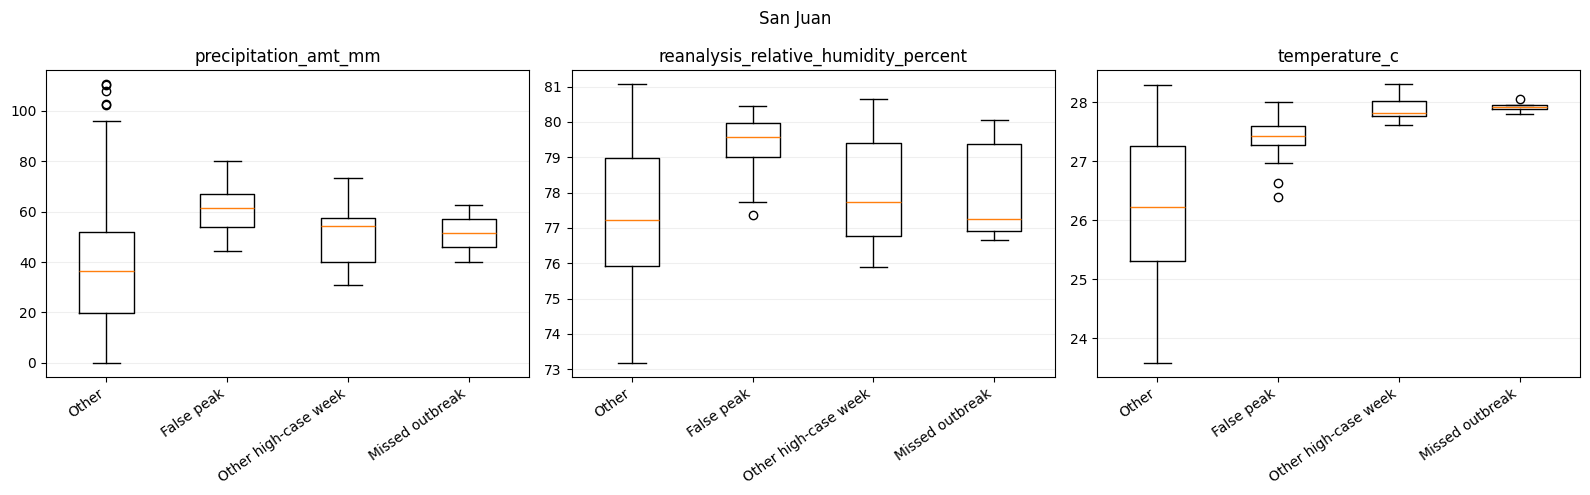

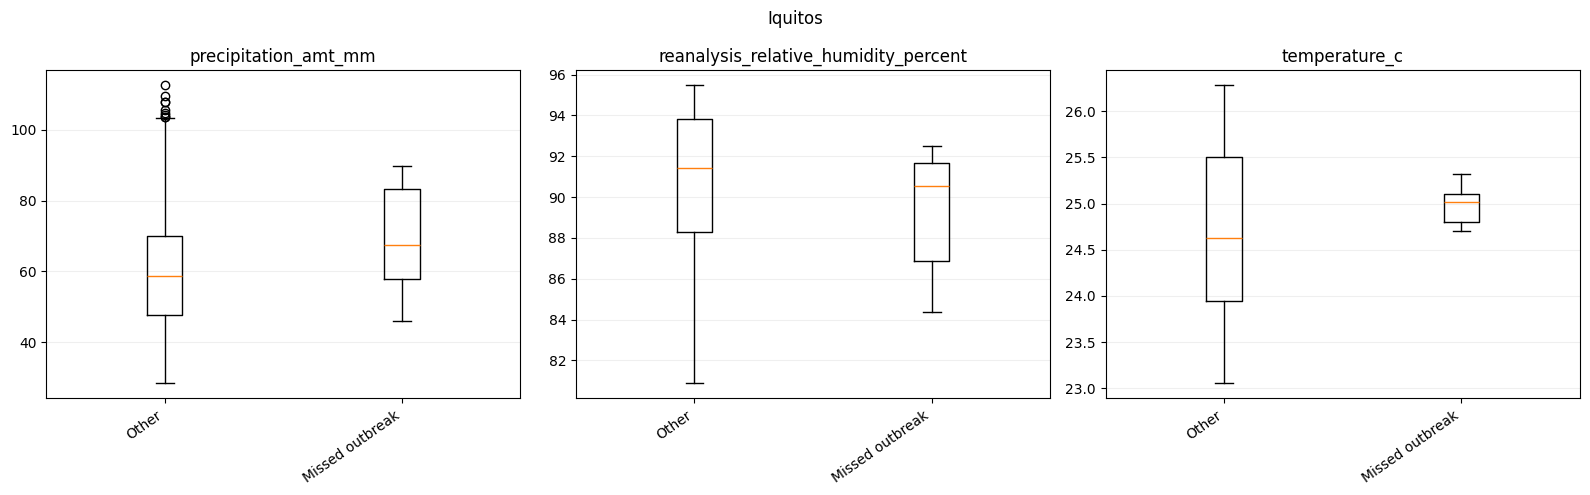

In [29]:
features_to_inspect = [
    "precipitation_amt_mm_previous_8w_mean",
    "reanalysis_relative_humidity_percent_previous_8w_mean",
    "temperature_c_previous_8w_mean",
]

for city in ["sj", "iq"]:
    frame = analysis.loc[analysis.city.eq(city)]
    groups = frame["error_group"].unique()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, feature in zip(axes, features_to_inspect):
        values = [
            frame.loc[frame.error_group.eq(group), feature]
            .dropna()
            .to_numpy()
            for group in groups
        ]

        ax.boxplot(values)
        ax.set_xticks(range(1, len(groups) + 1))
        ax.set_xticklabels(groups, rotation=35, ha="right")
        ax.set_title(feature.replace("_previous_8w_mean", ""))
        ax.grid(axis="y", alpha=0.2)

    fig.suptitle(CITY_NAMES[city])
    fig.tight_layout()
    plt.show()

In [30]:
anomaly_columns = []

for feature in features_to_inspect:
    anomaly = f"{feature}_seasonal_anomaly"
    analysis[anomaly] = np.nan
    anomaly_columns.append(anomaly)

    for city in ["sj", "iq"]:
        mask = analysis.city.eq(city)
        cutoff = analysis.loc[mask, "week_start_date"].min()

        historical_weather = weather.loc[
            weather.city.eq(city)
            & weather.week_start_date.lt(cutoff)
        ]

        seasonal_median = historical_weather.groupby(
            "weekofyear"
        )[feature].median()

        analysis.loc[mask, anomaly] = (
            analysis.loc[mask, feature]
            - analysis.loc[mask, "weekofyear"].map(seasonal_median)
        )

display(
    analysis.groupby(["city", "error_group"])[anomaly_columns]
    .median()
    .T
    .round(2)
)

city                                                            iq        \
error_group                                        Missed outbreak Other   
precipitation_amt_mm_previous_8w_mean_seasonal_...            7.55 -3.60   
reanalysis_relative_humidity_percent_previous_8...            4.36  1.89   
temperature_c_previous_8w_mean_seasonal_anomaly              -0.64 -0.05   

city                                                       sj                  \
error_group                                        False peak Missed outbreak   
precipitation_amt_mm_previous_8w_mean_seasonal_...      14.78            6.15   
reanalysis_relative_humidity_percent_previous_8...      -1.23           -3.66   
temperature_c_previous_8w_mean_seasonal_anomaly          0.52            0.87   

city                                                                           
error_group                                        Other Other high-case week  
precipitation_amt_mm_previous_8w_mean_seasonal_...  3.51                 7.77  
reanalysis_relative_humidity_percent_previous_8... -1.41                -3.24  
temperature_c_previous_8w_mean_seasonal_anomaly     0.58                 1.02

In [31]:
sj_other = analysis.loc[
    analysis.city.eq("sj")
    & analysis.error_group.eq("Other")
].copy()

sj_other["direction"] = np.select(
    [
        sj_other.residual.lt(0),
        sj_other.residual.gt(0),
    ],
    ["Overprediction", "Underprediction"],
    default="Exact",
)

display(
    sj_other.groupby("direction")
    .agg(
        weeks=("actual", "size"),
        mean_actual=("actual", "mean"),
        mean_prediction=(PREDICTION, "mean"),
        mae=("absolute_error", "mean"),
        total_error=("absolute_error", "sum"),
    )
    .round(2)
)

,weeks,mean_actual,mean_prediction,mae,total_error
direction,,,,,
Exact,8,11.88,11.88,0.00,0
Overprediction,173,14.12,28.49,14.38,2487
Underprediction,32,17.94,11.56,6.38,204


In [32]:
sj = analysis.loc[analysis.city.eq("sj")].copy()
sj["year"] = sj.week_start_date.dt.year

display(
    sj.groupby("year")
    .agg(
        actual_mean=("actual", "mean"),
        prediction_mean=(PREDICTION, "mean"),
        bias=("residual", "mean"),
        mae=("absolute_error", "mean"),
    )
    .round(2)
)

,actual_mean,prediction_mean,bias,mae
year,,,,
2003,23.46,28.54,-5.09,10.11
2004,11.73,33.94,-22.21,22.75
2005,34.71,45.85,-11.13,22.21
2006,10.58,25.44,-14.87,15.02
2007,37.87,36.62,1.25,13.52
2008,6.24,12.41,-6.18,6.18


In [33]:
feature = "precipitation_amt_mm_previous_16w_mean"

missing_check = analysis.assign(
    weather_missing=analysis[feature].isna()
)

display(
    missing_check.groupby(
        ["city", "error_group", "weather_missing"]
    )
    .agg(
        weeks=("actual", "size"),
        mae=("absolute_error", "mean"),
    )
    .round(2)
)

weeks    mae
city error_group          weather_missing              
iq   Missed outbreak      False               13  31.23
                          True                 3  24.00
     Other                False              111   4.28
                          True                29   4.90
sj   False peak           False               18  43.11
                          True                 3  34.67
     Missed outbreak      False               11  46.64
     Other                False              184  11.60
                          True                29  19.17
     Other high-case week False               15  13.13